In [1]:
%pip install line_profiler

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install gprofiler-official

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pyinstrument


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [5]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [6]:
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # [km^3/s^2] gm of the sun
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22

rubin_location = EarthLocation.from_geodetic( 
        lon=-70.7366*u.deg,   # longitude (west is negative)
        lat=-30.2407*u.deg,   # latitude
        height=2647*u.m       # elevation
        
    )

def get_earth_and_observer(obstime_str): # 1.47 ms -> 1.27 ms
    obstime = Time(obstime_str)
    
    obs_geo = rubin_location.get_gcrs(obstime)
    r_obs =  obs_geo.cartesian.xyz.to_value(u.km).T
    
    # earth's barycentric vector rel to sun aka center of solsys to earth
    with solar_system_ephemeris.set('de432s'): 
        rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

    # convert to km and km/s arrays in cartesian coordinate system
    rE  = rE_bary.xyz.to_value(u.km).T #rE goes from sun to earth center
    vE  = vE_bary.xyz.to_value(u.km/u.s).T

      #vE goes from sun to earth center

    return obstime, rE, vE, r_obs
       
# creates a right-handed vector basis that points to object from observer
def sky_basis(ra_rad, dec_rad): #its already fast w 5.32 us
        l_hat = np.array([np.cos(dec_rad)*np.cos(ra_rad), # vector that points to object's pos on sky from observer
                          np.cos(dec_rad)*np.sin(ra_rad),
                          np.sin(dec_rad)])
        e_ra  = np.array([-np.sin(ra_rad), np.cos(ra_rad), 0.0]) # vector towards increasing RA - points east, 90 deg to l_hat
        e_dec = np.array([-np.sin(dec_rad)*np.cos(ra_rad), # vector towards increasing dec - points north
                          -np.sin(dec_rad)*np.sin(ra_rad),
                          np.cos(dec_rad)])
        return l_hat, e_ra, e_dec # turning angular rates into linear velocities


# split from obs_to_geocentric_state
def compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day): 
        
        # converting from degrees to radians
        ra  = np.deg2rad(ra_deg) 
        dec = np.deg2rad(dec_deg)
        l_hat, e_ra, e_dec = sky_basis(ra, dec)
         # angular rate conversion from deg/day to rad/s
        dra  = np.deg2rad(dra_deg_per_day)  / 86400.0
        ddec = np.deg2rad(ddec_deg_per_day) / 86400.0

        v_hat = (dra * e_ra + ddec * e_dec)

        return l_hat, v_hat

# converts vectors to geocentric state vectors 
def observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms): 
    
        

        d_km = d_au * AU_km
        # multiplying l_hat by the rand dist. value gives actual geocentric pos vector of obj
        r_geo = np.outer(d_km, l_hat)  # vector from earth center to obj
        #r_geo = (d_au * AU_km) * l_hat
        #v_geo = ddot_kms * l_hat + (d_au * AU_km) * v_hat

        # speed
        v_rad = np.outer(ddot_kms, l_hat)
        v_tan = np.outer(d_km, v_hat)
        #v_tan = d_km * v_hat
        v_geo = v_rad + v_tan
        
        return r_geo, v_geo

#l_hat, v_hat = compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)

#converts geocentric vectors to heliocentric vectors 
def geo_to_topo(r_geo_km, v_geo_kms, rE, vE, r_obs, obstime):
        # convert r_geo, v_geo for obj to heliocentric r_topo, v_topo for an observer at rubin
        # from center of earth to an observer now at rubin
        obstime = Time(obstime)
        # earth's barycentric (heliocentric) state was done in previous step
        # so was observer's offset from center of earth
        # adding the offsets
        r_topo = rE + r_obs + r_geo_km
        v_topo = vE + v_geo_kms
        return r_topo, v_topo # asteroid position, vec going from sun to asteroid assuming youre at rubin

def to_keplerian_adam(r_helio, v_helio, obstime):
    r_vec = np.array(r_helio, dtype=float)
    v_vec = np.array(v_helio, dtype=float)

    if r_vec.ndim == 1:
        r_vec = r_vec[np.newaxis, :]
        v_vec = v_vec[np.newaxis, :]

    cartesian_coordinates = CartesianCoordinates.from_kwargs(
    x=r_vec[:, 0] / KM_P_AU,
    y=r_vec[:, 1] / KM_P_AU,
    z=r_vec[:, 2] / KM_P_AU,
    vx=v_vec[:, 0] / KM_P_AU * S_P_DAY,
    vy=v_vec[:, 1] / KM_P_AU * S_P_DAY,
    vz=v_vec[:, 2] / KM_P_AU * S_P_DAY,
    time=Timestamp.from_astropy(obstime),
    origin=Origin.from_kwargs(code=pa.repeat("SUN", len(r_vec))),
    frame="equatorial" # ecliptic is the other choice
    )

    keplerian_coordinates = cartesian_coordinates.to_keplerian()


    # Might be useful to store them into an orbits object:
    orbits = Orbits.from_kwargs(
        orbit_id=[f"orbit_{i:08d}" for i in range(len(cartesian_coordinates))],
        coordinates=cartesian_coordinates,
    )

    a_val = keplerian_coordinates.a[0].as_py()
    e_val = keplerian_coordinates.e[0].as_py()
    i_val = keplerian_coordinates.i[0].as_py()
    return a_val, e_val, i_val
# The Orbits class expects cartesian coordinates but its trivial to convert
    

def score_from_elements_interp(a_AU, e, H0, i0, interp4D):
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        
        return 0.0

    # clip to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,      0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)

    log_w = float(interp4D([[H0, a_cl, e_cl, i_cl]])[0])
    return 0.0 if not np.isfinite(log_w) else float(np.exp(log_w))
    
def score_from_elements(a_AU, e, H0, i0, grid4D, H_center, a_center, e_center, i_center): #without interpolation
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        
        return 0.0

    # clip to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,    0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)
    
    iH = int(np.argmin(np.abs(H_center - H0)))
    ia = int(np.argmin(np.abs(a_center - a_cl)))
    ie = int(np.argmin(np.abs(e_center - e_cl)))
    ii = int(np.argmin(np.abs(i_center - i_cl)))

    w=grid4D[iH, ia, ie, ii]
    if not np.isfinite(w) or w <= 0:
        return 0.0
    return float(w)



def compute_neomod3_weight(d_au, ddot_kms,array4D=array4D, H_center=H_center,
                           a_center=a_center, e_center=e_center, i_center=i_center,
                           l_hat = None, v_hat = None, 
                           ra_deg=10.0, dec_deg=20.0, 
                           dra_deg_per_day=0.12, ddec_deg_per_day=0.22,
                           H0=19.0, i0=25.9, obstime_str="2025-09-23T00:00:00"):

    
    if (l_hat is None) or (v_hat is None):
        l_hat, v_hat = compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
      
    obstime, rE, vE, r_obs = get_earth_and_observer(obstime_str) # first part, moved to start of cell


    r_geo, v_geo = observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    r_helio, v_helio = geo_to_topo(r_geo, v_geo, rE, vE, r_obs, obstime) 

    


    
    obstime = Time([obstime_str], scale="tdb")  # Note converted this to a list 
    a_val, e_val, i_val = to_keplerian_adam(r_helio, v_helio, obstime)


    
    
    #score = score_from_elements_interp(a_val, e_val, 19.0, i_val, interp4D)
    score = score_from_elements(
        a_val, e_val, H0, i_val,
        array4D, H_center, a_center, e_center, i_center
    )
    return score,a_val,e_val,i_val
    
    
    

        
        
    
    
    
    
                         
        
                   
                          

In [7]:
neo_score, a, e, i = compute_neomod3_weight(d_au=0.20, ddot_kms=3.0)


test_neomod = compute_neomod3_weight( 
    d_au = 0.20,
    ddot_kms = 3.0,
    
)

print("NEOMOD3 weight score, a, e , i:", test_neomod)
print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

NEOMOD3 weight score, a, e , i: (0.40217, 1.8147948989466378, 0.358504361404317, 26.36952675502365)
neo_score: 0.40217
a: 1.8147948989466378
e: 0.358504361404317
i: 26.36952675502365


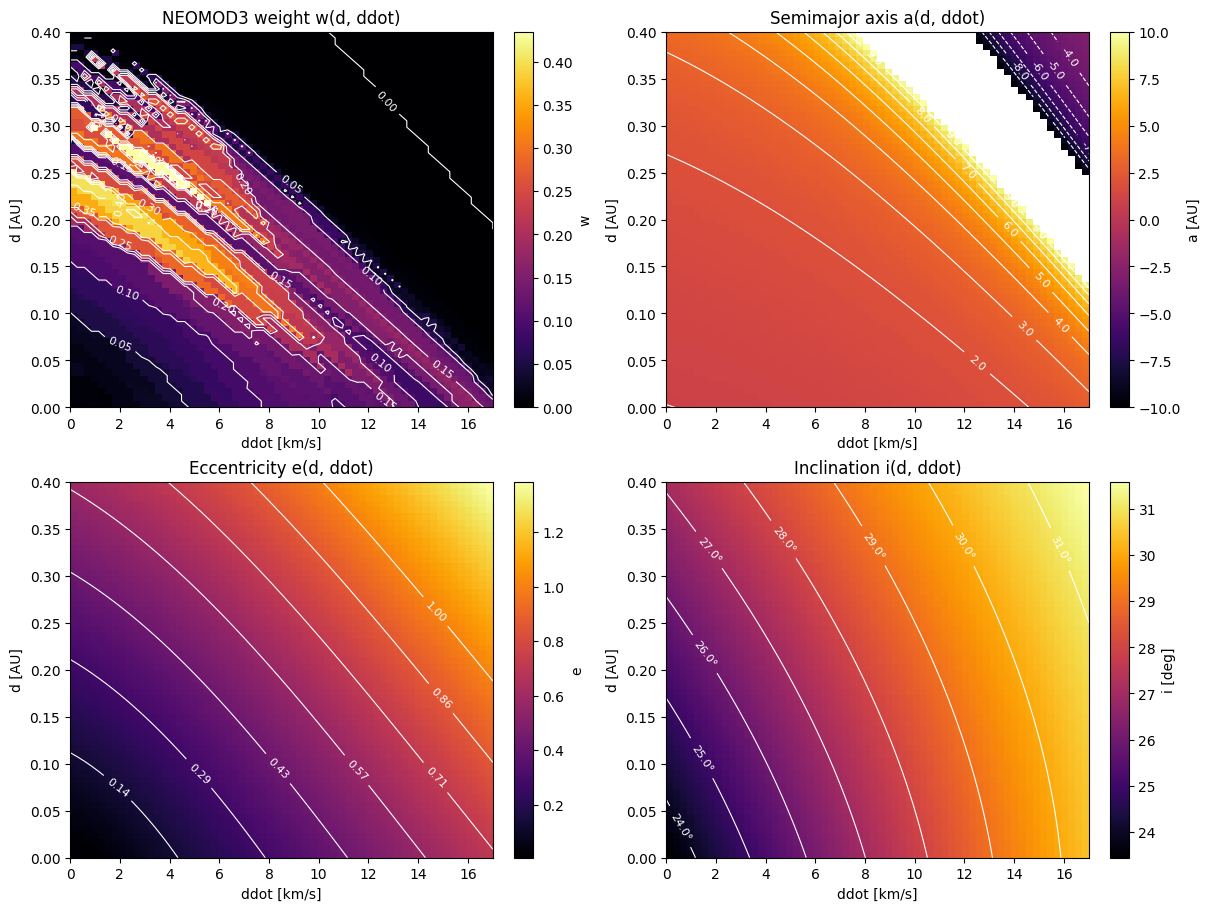

In [8]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 0.40, 60)   
v_vals = np.linspace(0.0, 17.0, 60)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)                       


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc = compute_neomod3_weight(d_au=d, ddot_kms=v) 
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(W, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#im1 = axs[0, 1].imshow(A, origin="lower", extent=extent, aspect="auto", cmap="inferno", vmin=-10, vmax=10)
#cont1 = axs[0,1].contour(v_vals, d_vals, A, levels=8, colors='white', linewidths=0.8)
#axs[0,1].clabel(cont1, inline=True, fontsize=8, fmt="%.2f")

#img1 = np.copy(im1)
#img1 = np.ma.masked_where(np.abs(img1) > 10, img1)
#plt.contour(x, y, img1, levels=np.linspace(-10, 10, 21))

#axs[0, 1].set_title("Semimajor axis a(d, ddot)")
#axs[0, 1].set_xlabel("ddot [km/s]")
#axs[0, 1].set_ylabel("d [AU]")
#fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()


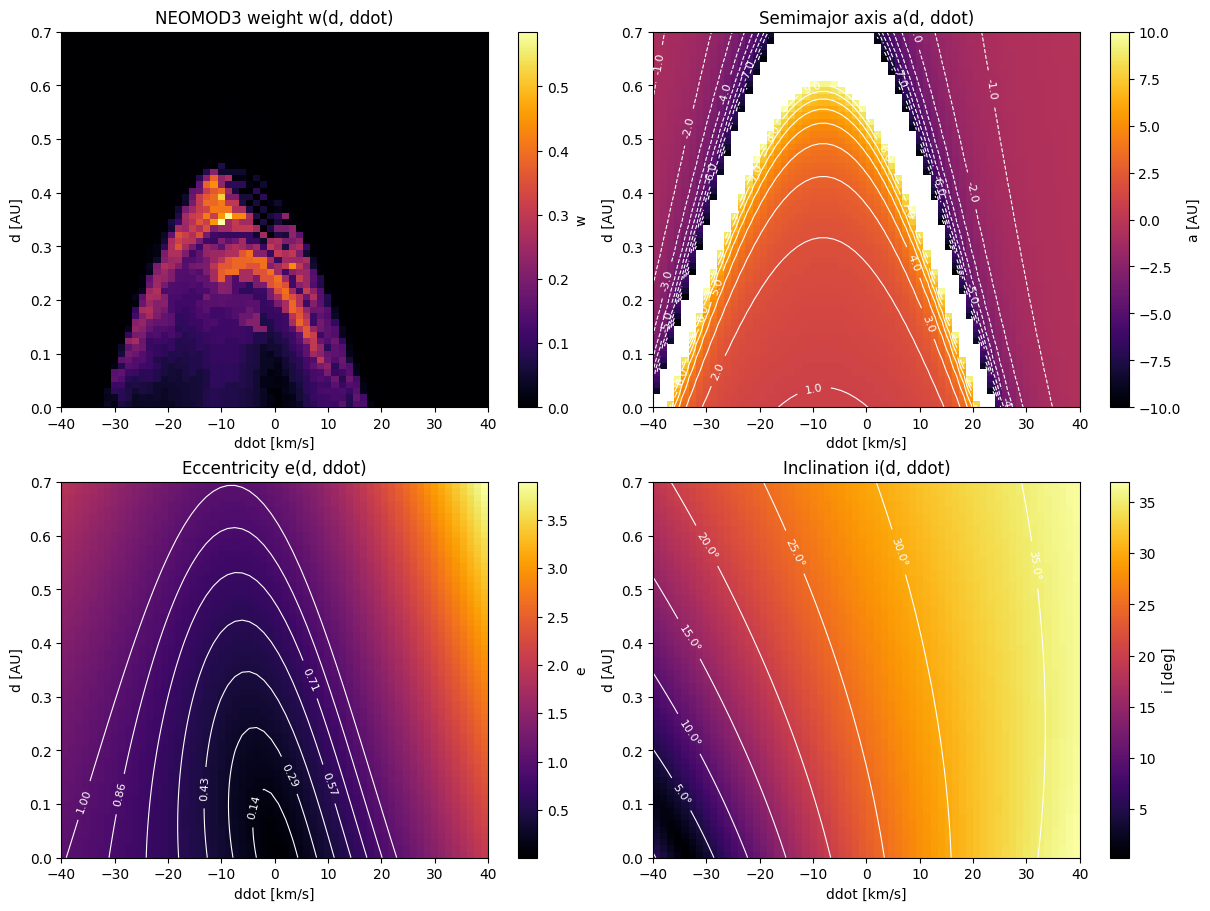

In [9]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 0.70, 60)   
v_vals = np.linspace(-40.0, 40.0, 60)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)                       


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc = compute_neomod3_weight(d_au=d, ddot_kms=v) 
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(W, origin="lower", extent=extent, aspect="auto", cmap="inferno")
#cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
#axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#im1 = axs[0, 1].imshow(A, origin="lower", extent=extent, aspect="auto", cmap="inferno", vmin=-10, vmax=10)
#cont1 = axs[0,1].contour(v_vals, d_vals, A, levels=8, colors='white', linewidths=0.8)
#axs[0,1].clabel(cont1, inline=True, fontsize=8, fmt="%.2f")

#img1 = np.copy(im1)
#img1 = np.ma.masked_where(np.abs(img1) > 10, img1)
#plt.contour(x, y, img1, levels=np.linspace(-10, 10, 21))

#axs[0, 1].set_title("Semimajor axis a(d, ddot)")
#axs[0, 1].set_xlabel("ddot [km/s]")
#axs[0, 1].set_ylabel("d [AU]")
#fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()


In [10]:
def radec_rates_to_ecliptic_rates1(ra_deg, dec_deg, dra_deg_day, ddec_deg_day):

    
    sc_eq = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        pm_ra_cosdec=dra_deg_day * u.deg / u.day,
        pm_dec=ddec_deg_day * u.deg / u.day,
        frame="icrs"
    )

    
    sc_ecl = sc_eq.transform_to(GeocentricTrueEcliptic())

    
    vlam  = sc_ecl.pm_lon_coslat.to(u.deg / u.day).value
    vbeta = sc_ecl.pm_lat.to(u.deg / u.day).value

    return vlam, vbeta

In [11]:
%load_ext line_profiler

In [12]:

def makeddotgrids():
    d_min, d_max, Nd = 0.05, 5.0, 10          # AU  
    v_min, v_max, Nv = -60.0, 60.0, 10         # km/s

    d_grid   = np.linspace(d_min, d_max, Nd)
    ddot_grid= np.linspace(v_min, v_max, Nv)
    return d_grid, ddot_grid
    
def weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,
                                        ra_deg, dec_deg, dra_deg_day, ddec_deg_day,
                                        H0=19.0, i0=25.9, obstime_str="2025-09-23T00:00:00"):
    w_sum = 0.0
    d_grid, ddot_grid = makeddotgrids()
    # loop 
    for d in d_grid:
        for vlos in ddot_grid:
            out = compute_neomod3_weight(d_au=d, ddot_kms=vlos, array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                            ra_deg=ra_deg, dec_deg=dec_deg,
                            dra_deg_per_day=dra_deg_day, ddec_deg_per_day=ddec_deg_day,
                            H0=H0, i0=i0, obstime_str=obstime_str)
            w = out[0] if isinstance(out, tuple) else float(out)
            w_sum += w
    return w_sum
    

    



In [13]:
%timeit -n 1 -r 3 weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,ra_deg, dec_deg, dra_deg_day=0.12, ddec_deg_day=0.22)


262 ms ± 2.38 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


In [14]:
#%prun weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,ra_deg, dec_deg, dra_deg_day=0.12, ddec_deg_day=0.22)


In [15]:
from IPython.display import HTML
from pyinstrument import Profiler
profiler = Profiler()
profiler.start()

weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center,ra_deg, dec_deg, dra_deg_day=0.12, ddec_deg_day=0.22)

profiler.stop()
profiler.print()
with open("profile_report.html", "w") as f:
    f.write(profiler.output_html())


  _     ._   __/__   _ _  _  _ _/_   Recorded: 17:54:51  Samples:  202
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.353     CPU time: 0.364
/   _/                      v5.1.1

Profile at /tmp/ipykernel_4187681/3656242287.py:4

0.352 <module>  /tmp/ipykernel_4187681/3656242287.py:1
└─ 0.352 weight_marginalized_over_d_and_ddot  /tmp/ipykernel_4187681/1470737377.py:9
   └─ 0.352 compute_neomod3_weight  /tmp/ipykernel_4187681/834276229.py:163
      ├─ 0.205 get_earth_and_observer  /tmp/ipykernel_4187681/834276229.py:12
      │  ├─ 0.139 EarthLocation.get_gcrs  astropy/coordinates/earth.py:717
      │  │     [56 frames hidden]  astropy, erfa
      │  ├─ 0.035 get_body_barycentric_posvel  astropy/coordinates/solar_system.py:338
      │  │     [3 frames hidden]  astropy
      │  │        0.035 _get_body_barycentric_posvel  astropy/coordinates/solar_system.py:199
      │  │        └─ 0.020 Segment.generate  jplephem/spk.py:202
      │  ├─ 0.016 Time.__init__  astropy/time/core.py:1951
   

In [16]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [17]:
ra0, dec0 = 0.0, 0.0
dra0, ddec0 = 0.12, 0.22        # deg/day
d0, vlos0 = 0.2, 3.0            # AU, km/s
t0 = "2025-09-23T00:00:00"

w_test = compute_neomod3_weight(
    d_au=d0, ddot_kms=vlos0,
    array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
    ra_deg=ra0, dec_deg=dec0, dra_deg_per_day=dra0, ddec_deg_per_day=ddec0,
    H0=19.0, i0=25.9, obstime_str=t0,
)
print("w_test:", w_test)


w_test: (0.35421, 1.714046950635696, 0.3089243577156695, 25.163625295298857)


In [19]:

# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0
obstime_str = "2025-09-23T00:00:00"

 
N_rate = 11
dra_vals  = np.linspace(-0.6, 0.6, N_rate)
ddec_vals = np.linspace(-0.6, 0.6, N_rate)


vlam_edges = np.linspace(-0.6, 0.6, 121)
vbet_edges = np.linspace(-0.6, 0.6, 121)


H = np.zeros((len(vbet_edges)-1, len(vlam_edges)-1), dtype=float)

for dra in dra_vals:
    for ddec in ddec_vals:
        vlam, vbet = radec_rates_to_ecliptic_rates1(ra0_deg, dec0_deg, dra, ddec)
        w_int = weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                    ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_day=dra, ddec_deg_day=ddec,
                                                    H0=19.0, i0=25.9, obstime_str=obstime_str)
        
        i = np.searchsorted(vlam_edges, vlam) - 1
        j = np.searchsorted(vbet_edges, vbet) - 1
        if 0 <= i < H.shape[1] and 0 <= j < H.shape[0]:
            H[j, i] += w_int

In [20]:
%timeit weight_marginalized_over_d_and_ddot(array4D, H_center, a_center, e_center, i_center, ra_deg, dec_deg, dra_deg_day = 0.12, ddec_deg_day=0.22,H0=19.0, i0=25.9, obstime_str="2025-09-23T00:00:00")

256 ms ± 340 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


/tmp/ipykernel_4187681/1125375196.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


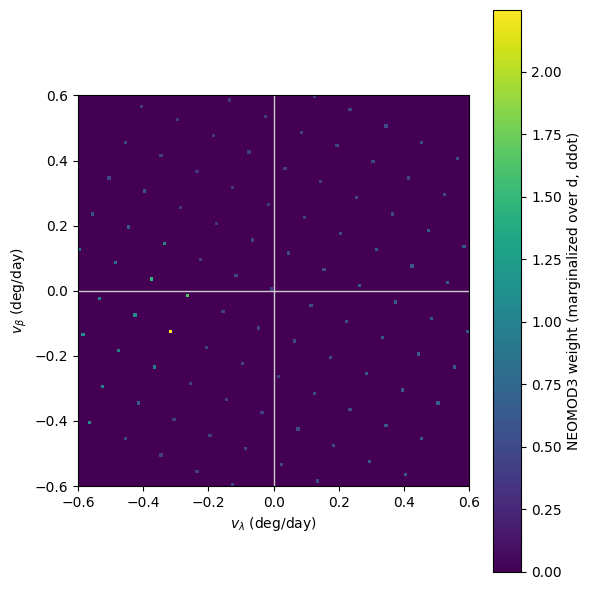

In [21]:

from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap="viridis", aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
#plt.title("v_lambda–v_beta distribution (integrated over d [0.05,5] AU, ddot [−60,60] km/s)\n"
#          f"{obstime_str}")
plt.tight_layout()
plt.show()